<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_5528/367185457.py:49: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Target Error Limit ($\epsilon$)', fontsize=12)


Running Algorithm 1 across different error limits...
Testing target error limit: 1.00e-01
  -> Achieved Error: 6.05e-02 | Queries: 42
Testing target error limit: 5.99e-02
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Achieved Error: 1.06e-01 | Queries: 350
Testing target error limit: 3.59e-02
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Achieved Error: 1.06e-01 | Queries: 350
Testing target error limit: 2.15e-02
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Achieved Error: 1.06e-01 | Queries: 350
Testing target error limit: 1.29e-02
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Achieved Error: 1.06e-01 | Queries: 350
Testing target error limit: 7.74e-03
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Achieved Error: 1.06e-01 | Queries: 350
Testing tar

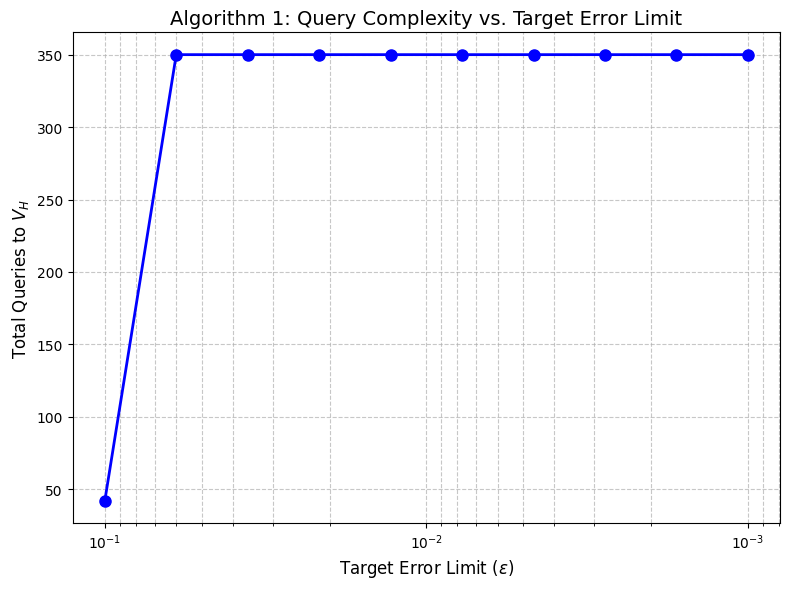

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import the integrated function from your algo.py script
from algo import algorithm1

def main():
    # 1. Prepare a target Hermitian matrix H (adapted from step2.ipynb)
    raw = np.array([
        [2.0 + 1j, 3.0],
        [-1.0, 4.0 - 2j]
    ], dtype=complex)
    
    H = (raw + raw.conj().T) / 2
    H = H / (np.linalg.norm(H, ord=2) + 0.1)  # Normalize so ||H|| <= 1
    
    # 2. Define a range of error limits to test
    # We test values from 10^-1 down to 10^-3 (logarithmically spaced)
    # Note: Going smaller than 10^-3 will require large polynomial degrees 
    # which can take a long time to simulate on standard classical hardware.
    error_limits = np.logspace(-1, -3, num=10)
    
    queries_list = []
    actual_errors = []
    
    print("Running Algorithm 1 across different error limits...")
    for err_lim in error_limits:
        print(f"Testing target error limit: {err_lim:.2e}")
        
        # Run algorithm 1 with a generously high max_deg to ensure convergence
        final_U, actual_err, total_queries = algorithm1(H, err_lim, max_deg=3001)
        
        queries_list.append(total_queries)
        actual_errors.append(actual_err)
        
        print(f"  -> Achieved Error: {actual_err:.2e} | Queries: {total_queries}")

    # 3. Plot the results
    plt.figure(figsize=(8, 6))
    
    # Plot Number of Queries vs Error Limit
    plt.plot(error_limits, queries_list, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
    
    # Format the plot
    plt.xscale('log')          # Log scale for error limit
    plt.gca().invert_xaxis()   # Invert X axis so smaller errors (higher precision) are on the right
    
    plt.title('Algorithm 1: Query Complexity vs. Target Error Limit', fontsize=14)
    plt.xlabel('Target Error Limit ($\epsilon$)', fontsize=12)
    plt.ylabel('Total Queries to $V_H$', fontsize=12)
    
    # Add a grid for easier readability
    plt.grid(True, which="both", ls="--", alpha=0.7)
    
    # Save and display the plot
    plt.tight_layout()
    plt.savefig("query_vs_error.png", dpi=300)
    print("\nPlot saved as 'query_vs_error.png'")
    plt.show()

if __name__ == "__main__":
    main()

<>:52: SyntaxWarning: invalid escape sequence '\e'
<>:52: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_5528/2091046092.py:52: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Target Error Limit ($\epsilon$)', fontsize=12)


Running Algorithm 1 for various ||H|| values (High Resolution)...

--- Testing for ||H|| = 0.5 ---

--- Testing for ||H|| = 0.8 ---
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.

--- Testing for ||H|| = 0.9 ---
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.

--- Testing for ||H|| = 0.99 ---
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.
  -> Notice: Classical QSVT angle solver reached numerical instability limit at deg 105.


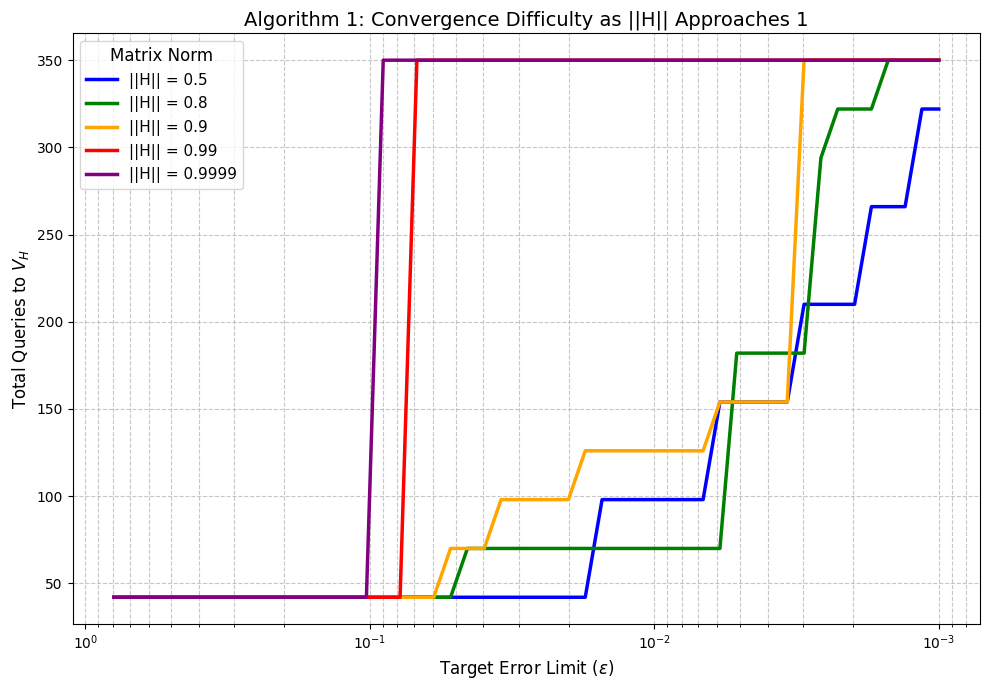

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Import the integrated function from your algo.py script
from algo import algorithm1

def main():
    # 1. Prepare a base Hermitian matrix H and normalize it so its norm is EXACTLY 1.0
    raw = np.array([
        [2.0 + 1j, 3.0],
        [-1.0, 4.0 - 2j]
    ], dtype=complex)
    
    H_raw = (raw + raw.conj().T) / 2
    H_base = H_raw / np.linalg.norm(H_raw, ord=2) 
    
    h_norms = [0.5, 0.8, 0.9, 0.99, 0.9999]
    
    # --- CHANGED HERE: Increased num=10 to num=50 for a much higher resolution plot ---
    error_limits = np.logspace(-0.1, -3, num=50)
    
    plt.figure(figsize=(10, 7))
    colors = ['blue', 'green', 'orange', 'red', 'purple']
    
    # Removed the discrete markers ('o', 's', etc.) because with 50 points, 
    # they will overlap and look messy. A pure line plot looks much more fluent!
    print("Running Algorithm 1 for various ||H|| values (High Resolution)...")
    
    for idx, norm_val in enumerate(h_norms):
        H_target = H_base * norm_val
        print(f"\n--- Testing for ||H|| = {norm_val} ---")
        
        queries_list = []
        actual_errors = []
        
        for err_lim in error_limits:
            final_U, actual_err, total_queries = algorithm1(H_target, err_lim, max_deg=3001)
            
            queries_list.append(total_queries)
            actual_errors.append(actual_err)
            
        # Plotting purely with lines for maximum fluency
        plt.plot(error_limits, queries_list, linestyle='-', 
                 color=colors[idx], linewidth=2.5, 
                 label=f'||H|| = {norm_val}')

    # 4. Format the plot
    plt.xscale('log')          
    plt.gca().invert_xaxis()   
    
    plt.title('Algorithm 1: Convergence Difficulty as ||H|| Approaches 1', fontsize=14)
    plt.xlabel('Target Error Limit ($\epsilon$)', fontsize=12)
    plt.ylabel('Total Queries to $V_H$', fontsize=12)
    
    plt.legend(title="Matrix Norm", fontsize=11, title_fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("query_vs_error_fluent.png", dpi=300)
    print("\nPlot saved as 'query_vs_error_fluent.png'")
    plt.show()

if __name__ == "__main__":
    main()